## 04 - Classic ML baseline (TF-IDF + SVM) và so sánh với PhoBERT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NLP_project/processed")
ROOT_DIR = Path("/content/drive/MyDrive/NLP_project")

train = pd.read_csv(BASE_DIR / "train_seg.csv")
val = pd.read_csv(BASE_DIR / "validation_seg.csv")
test = pd.read_csv(BASE_DIR / "test_seg.csv")

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)


Mounted at /content/drive
Train: (11426, 4)
Validation: (1583, 4)
Test: (3166, 4)


### TF-IDF vectorize

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
)

X_train = vectorizer.fit_transform(train["sentence_seg"])
X_test = vectorizer.transform(test["sentence_seg"])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (11426, 10000)
X_test : (3166, 10000)


### Train SVM cho Sentiment và Topic

In [3]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Sentiment
svm_sentiment = LinearSVC(
    class_weight="balanced",
    random_state=42
)
svm_sentiment.fit(X_train, train["sentiment"])
sent_preds = svm_sentiment.predict(X_test)

print("=== SVM - Sentiment ===")
print(classification_report(
    test["sentiment"],
    sent_preds,
    zero_division=0
))

# Topic
svm_topic = LinearSVC(
    class_weight="balanced",
    random_state=42
)
svm_topic.fit(X_train, train["topic"])
topic_preds = svm_topic.predict(X_test)

print("\n=== SVM - Topic ===")
print(classification_report(
    test["topic"],
    topic_preds,
    zero_division=0
))


=== SVM - Sentiment ===
              precision    recall  f1-score   support

    negative       0.89      0.94      0.91      1409
     neutral       0.44      0.32      0.37       167
    positive       0.93      0.91      0.92      1590

    accuracy                           0.89      3166
   macro avg       0.75      0.72      0.73      3166
weighted avg       0.89      0.89      0.89      3166


=== SVM - Topic ===
                  precision    recall  f1-score   support

        facility       0.90      0.92      0.91       145
        lecturer       0.93      0.90      0.91      2290
          others       0.46      0.45      0.46       159
training_program       0.65      0.73      0.69       572

        accuracy                           0.85      3166
       macro avg       0.74      0.75      0.74      3166
    weighted avg       0.85      0.85      0.85      3166



### Hàm tính metrics chi tiết theo từng lớp (dùng chung cho SVM và PhoBERT)

In [4]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
)

def per_class_metrics(y_true, y_pred, labels, model_name, task_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    rows = []

    for i, label in enumerate(labels):
        rows.append({
            "task": task_name,
            "model": model_name,
            "class": label,
            "precision": round(precision[i], 3),
            "recall": round(recall[i], 3),
            "f1": round(f1[i], 3),
            "support": int(support[i]),
        })

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0,
    )

    acc = accuracy_score(y_true, y_pred)

    rows.append({
        "task": task_name,
        "model": model_name,
        "class": "MACRO_AVG",
        "precision": round(macro_p, 3),
        "recall": round(macro_r, 3),
        "f1": round(macro_f1, 3),
        "support": len(y_true),
    })

    rows.append({
        "task": task_name,
        "model": model_name,
        "class": "ACCURACY",
        "precision": None,
        "recall": None,
        "f1": round(acc, 3),
        "support": len(y_true),
    })

    return pd.DataFrame(rows)


SENT_LABELS = ["negative", "neutral", "positive"]
TOPIC_LABELS = ["lecturer", "training_program", "facility", "others"]


### Tính metrics cho SVM, lưu file

In [5]:
svm_sent_df = per_class_metrics(
    test["sentiment"],
    sent_preds,
    SENT_LABELS,
    "SVM",
    "sentiment",
)

svm_topic_df = per_class_metrics(
    test["topic"],
    topic_preds,
    TOPIC_LABELS,
    "SVM",
    "topic",
)

svm_all = pd.concat(
    [svm_sent_df, svm_topic_df],
    ignore_index=True,
)

svm_all.to_csv(
    BASE_DIR / "svm_results.csv",
    index=False,
    encoding="utf-8-sig",
)

print(svm_all.to_string(index=False))


     task model            class  precision  recall    f1  support
sentiment   SVM         negative      0.885   0.940 0.912     1409
sentiment   SVM          neutral      0.438   0.317 0.368      167
sentiment   SVM         positive      0.934   0.909 0.921     1590
sentiment   SVM        MACRO_AVG      0.752   0.722 0.734     3166
sentiment   SVM         ACCURACY        NaN     NaN 0.892     3166
    topic   SVM         lecturer      0.930   0.900 0.915     2290
    topic   SVM training_program      0.650   0.734 0.690      572
    topic   SVM         facility      0.899   0.917 0.908      145
    topic   SVM           others      0.462   0.453 0.457      159
    topic   SVM        MACRO_AVG      0.735   0.751 0.742     3166
    topic   SVM         ACCURACY        NaN     NaN 0.848     3166


### Gộp với kết quả PhoBERT

File `test_predictions.csv` của PhoBERT được lưu trong `NLP_project/` (thư mục cha), không phải `NLP_project/processed/`, nên cell bên dưới sử dụng `ROOT_DIR`.

Nếu file chưa tồn tại, chạy cell debug để kiểm tra vị trí file.

In [6]:
# Debug: locate PhoBERT predictions if the expected path does not exist.
import subprocess

result = subprocess.run(
    [
        "find",
        "/content/drive/MyDrive/NLP_project",
        "-iname",
        "test_predictions.csv",
    ],
    capture_output=True,
    text=True,
)

if result.stdout.strip():
    print("Tìm thấy tại:")
    print(result.stdout)
else:
    print(
        "KHÔNG TÌM THẤY test_predictions.csv. "
        "Cần chạy lại bước lưu predictions trong notebook PhoBERT."
    )


Tìm thấy tại:
/content/drive/MyDrive/NLP_project/test_predictions.csv



In [7]:
phobert_path = ROOT_DIR / "test_predictions.csv"

if not phobert_path.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file PhoBERT tại: {phobert_path}\n"
        "Hãy chạy cell debug phía trên để kiểm tra vị trí file."
    )

phobert_test = pd.read_csv(phobert_path)

required_cols = {
    "true_sentiment",
    "pred_sentiment",
    "true_topic",
    "pred_topic",
}

missing_cols = required_cols - set(phobert_test.columns)

if missing_cols:
    raise ValueError(
        f"PhoBERT predictions thiếu các cột: {sorted(missing_cols)}"
    )

phobert_sent_df = per_class_metrics(
    phobert_test["true_sentiment"],
    phobert_test["pred_sentiment"],
    SENT_LABELS,
    "PhoBERT",
    "sentiment",
)

phobert_topic_df = per_class_metrics(
    phobert_test["true_topic"],
    phobert_test["pred_topic"],
    TOPIC_LABELS,
    "PhoBERT",
    "topic",
)

full_comparison = pd.concat(
    [
        svm_sent_df,
        phobert_sent_df,
        svm_topic_df,
        phobert_topic_df,
    ],
    ignore_index=True,
)

full_comparison.to_csv(
    BASE_DIR / "full_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print(full_comparison.to_string(index=False))


     task   model            class  precision  recall    f1  support
sentiment     SVM         negative      0.885   0.940 0.912     1409
sentiment     SVM          neutral      0.438   0.317 0.368      167
sentiment     SVM         positive      0.934   0.909 0.921     1590
sentiment     SVM        MACRO_AVG      0.752   0.722 0.734     3166
sentiment     SVM         ACCURACY        NaN     NaN 0.892     3166
sentiment PhoBERT         negative      0.926   0.974 0.949     1409
sentiment PhoBERT          neutral      0.711   0.485 0.577      167
sentiment PhoBERT         positive      0.963   0.951 0.957     1590
sentiment PhoBERT        MACRO_AVG      0.866   0.803 0.828     3166
sentiment PhoBERT         ACCURACY        NaN     NaN 0.937     3166
    topic     SVM         lecturer      0.930   0.900 0.915     2290
    topic     SVM training_program      0.650   0.734 0.690      572
    topic     SVM         facility      0.899   0.917 0.908      145
    topic     SVM           others

### Biểu đồ so sánh F1 theo lớp

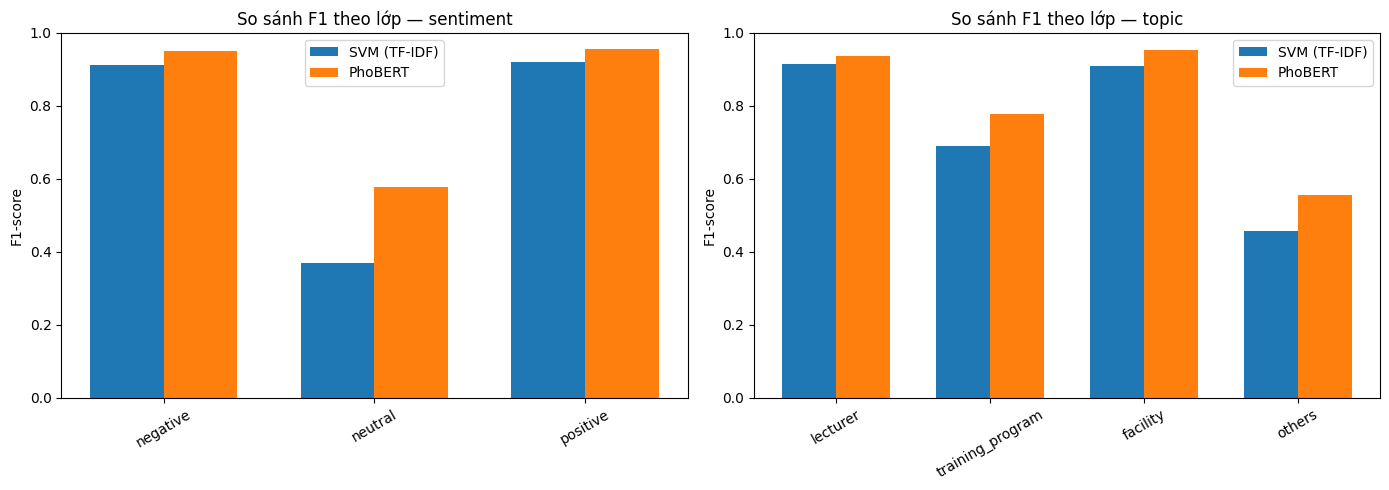

Đã lưu biểu đồ: /content/drive/MyDrive/NLP_project/processed/f1_comparison_chart.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task, labels in [
    (axes[0], "sentiment", SENT_LABELS),
    (axes[1], "topic", TOPIC_LABELS),
]:
    sub = full_comparison[
        (full_comparison["task"] == task)
        & (full_comparison["class"].isin(labels))
    ]

    x = np.arange(len(labels))
    width = 0.35

    svm_f1 = [
        sub[
            (sub["model"] == "SVM")
            & (sub["class"] == label)
        ]["f1"].iloc[0]
        for label in labels
    ]

    phobert_f1 = [
        sub[
            (sub["model"] == "PhoBERT")
            & (sub["class"] == label)
        ]["f1"].iloc[0]
        for label in labels
    ]

    ax.bar(
        x - width / 2,
        svm_f1,
        width,
        label="SVM (TF-IDF)",
    )

    ax.bar(
        x + width / 2,
        phobert_f1,
        width,
        label="PhoBERT",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30)
    ax.set_ylabel("F1-score")
    ax.set_title(f"So sánh F1 theo lớp — {task}")
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()

chart_path = BASE_DIR / "f1_comparison_chart.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ: {chart_path}")
